In [17]:
#Librerias a usar
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#Lectura
ruta = "../data/raw/spain_energy_market.csv"
df = pd.read_csv(ruta) 

In [19]:
display(df.info())
print(f"Tiene la cantidad de {df.shape[0]} filas y {df.shape[1]} columnas")
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  40212 non-null  object 
 1   id        40212 non-null  int64  
 2   name      34734 non-null  object 
 3   geoid     10956 non-null  float64
 4   geoname   10956 non-null  object 
 5   value     40212 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.8+ MB


None

Tiene la cantidad de 40212 filas y 6 columnas


,datetime,id,name,geoid,geoname,value
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500


In [20]:
#Datos faltantes
valores_faltantes = df.isnull().sum().sort_values(ascending= False)
print("Valores faltantes ordenados: ")
display(valores_faltantes.to_frame('Cantidad de valores faltantes'))

#Elementos duplicados
print(f"\nElementos duplicados: {df.duplicated().sum()}")
#Resumen estadistico 
print("\nResumen estadistico:")
display(df.describe())

Valores faltantes ordenados: 


,Cantidad de valores faltantes
geoname,29256
geoid,29256
name,5478
datetime,0
id,0
value,0



Elementos duplicados: 0

Resumen estadistico:


,id,geoid,value
count,40212.000000,10956.000000,4.021200e+04
mean,2767.757286,2.000000,1.325967e+05
std,4014.664966,0.816534,2.147129e+05
min,3.000000,1.000000,-1.426133e+06
25%,600.000000,1.000000,5.112708e+01
50%,602.000000,2.000000,2.778778e+04
75%,1334.000000,3.000000,1.615399e+05
max,10258.000000,3.000000,2.584390e+06


In [21]:
# Porcentaje de valores faltantes
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

display(missing_pct.to_frame('Porcentaje de nulos'))


,Porcentaje de nulos
geoname,72.754402
geoid,72.754402
name,13.622799
datetime,0.000000
id,0.000000
value,0.000000


In [22]:
#Covertimos en fecha
df['datetime'] = pd.to_datetime(df['datetime'])

#convertimos a int
df['geoid'] = df['geoid'].astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  40212 non-null  datetime64[ns]
 1   id        40212 non-null  int64         
 2   name      34734 non-null  object        
 3   geoid     10956 non-null  Int64         
 4   geoname   10956 non-null  object        
 5   value     40212 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.9+ MB


In [23]:
cols_obj = df.select_dtypes(include='object').columns
cols_num = df.select_dtypes(include=['int64', 'float64'])

for col in cols_obj:
    display(df[col].value_counts(dropna=False))
    cantidad = len(df[col].value_counts(dropna=False))
    display(cantidad)


name
NaN                                                                       5478
Precio mercado SPOT Diario FRA                                            1826
Precio mercado SPOT Diario POR                                            1826
Energía asignada en Mercado SPOT Diario España                            1826
Precio mercado SPOT Diario ESP                                            1826
Energía asignada en Mercado SPOT Diario Francia                           1826
Generación programada PBF Gas Natural Cogeneración                        1826
Generación programada PBF Solar fotovoltaica                              1826
Generación programada PBF UGH + no UGH                                    1826
Generación programada PBF Eólica                                          1825
Generación programada PBF total                                           1825
Demanda programada PBF total                                              1825
Demanda real                                   

21

geoname
NaN         29256
España       3652
Francia      3652
Portugal     3652
Name: count, dtype: int64

4

In [24]:
df.assign(
    es_cero = df['value'] == 0,
    es_negativo = df['value'] < 0
).groupby('id').agg(
    ceros=('es_cero', 'sum'),
    negativos=('es_negativo', 'sum'),
    total=('value', 'size')
).sort_values('negativos', ascending=False)


,ceros,negativos,total
id,,,
1117,118,185,1619
1118,194,48,712
4,0,0,1825
3,0,0,1824
9,0,0,1793
14,0,0,1826
600,0,0,10956
17,0,0,1826
602,0,0,1826


In [25]:
df['name'] = df['name'].fillna('Desconocido')
df = df[df['name'] != 'Desconocido']
df.shape

(34734, 6)

In [26]:
#Datos faltantes
valores_faltantes_name = df['name'].isnull().sum()
print("Valores faltantes en 'name':")
print(valores_faltantes_name)
df.info()

Valores faltantes en 'name':
0
<class 'pandas.core.frame.DataFrame'>
Index: 34734 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  34734 non-null  datetime64[ns]
 1   id        34734 non-null  int64         
 2   name      34734 non-null  object        
 3   geoid     5478 non-null   Int64         
 4   geoname   5478 non-null   object        
 5   value     34734 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.9+ MB


# Eda

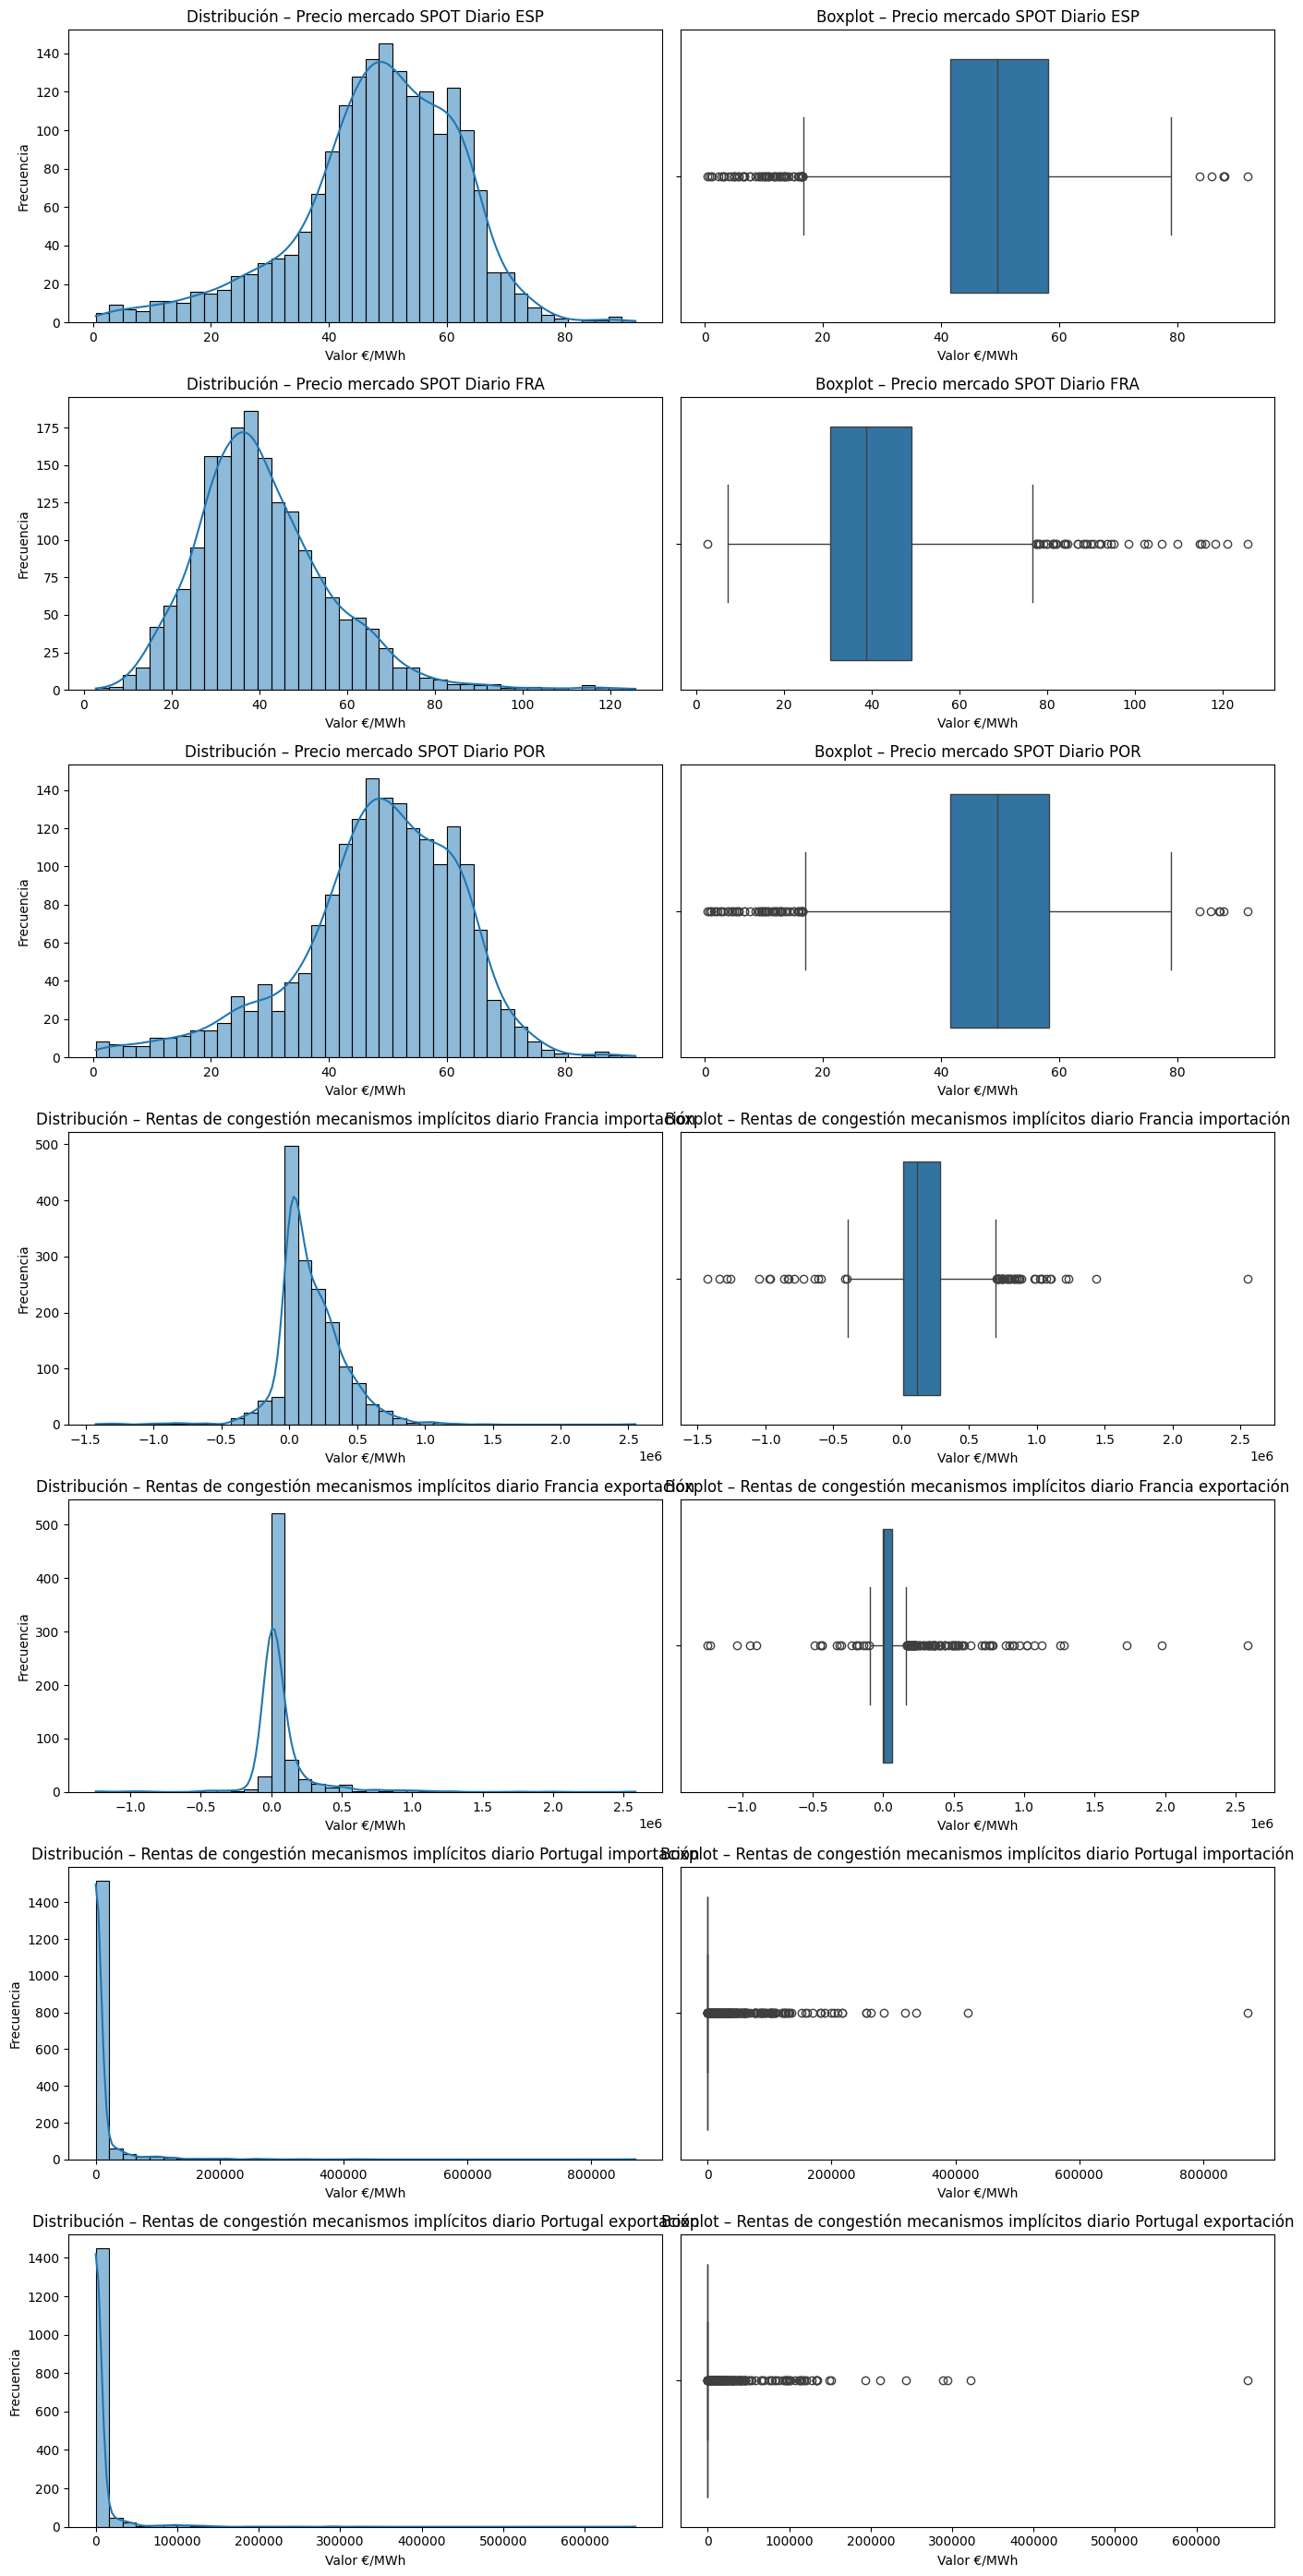

In [35]:
series = [
    'Precio mercado SPOT Diario ESP',
    'Precio mercado SPOT Diario FRA',
    'Precio mercado SPOT Diario POR',
    'Rentas de congestión mecanismos implícitos diario Francia importación',
    'Rentas de congestión mecanismos implícitos diario Francia exportación',
    'Rentas de congestión mecanismos implícitos diario Portugal importación',
    'Rentas de congestión mecanismos implícitos diario Portugal exportación'
]

series2 = [
    'Energía asignada en Mercado SPOT Diario España',
    'Energía asignada en Mercado SPOT Diario Francia',
    'Demanda real',
    'Demanda programada PBF total',
    'Generación programada PBF Gas Natural Cogeneración',
    'Generación programada PBF Solar fotovoltaica',
    'Generación programada PBF Eólica',
    'Generación programada PBF Nuclear',
    'Generación programada PBF Carbón',
    'Generación programada PBF Ciclo combinado',
    'Generación programada PBF UGH + no UGH',
    'Generación programada PBF Turbinación bombeo',
    'Generación programada PBF total'
]

fig, axes = plt.subplots(nrows=len(series),ncols=2,figsize=(14, 4 * len(series)))

for i, serie in enumerate(series):
    data = df[df['name'] == serie]['value']

    # Histograma + KDE
    sns.histplot(
        data=data,
        bins=40,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"Distribución – {serie}")
    axes[i, 0].set_xlabel("Valor €/MWh")
    axes[i, 0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(
        x=data,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot – {serie}")
    axes[i, 1].set_xlabel("Valor €/MWh")

plt.tight_layout()
plt.show()


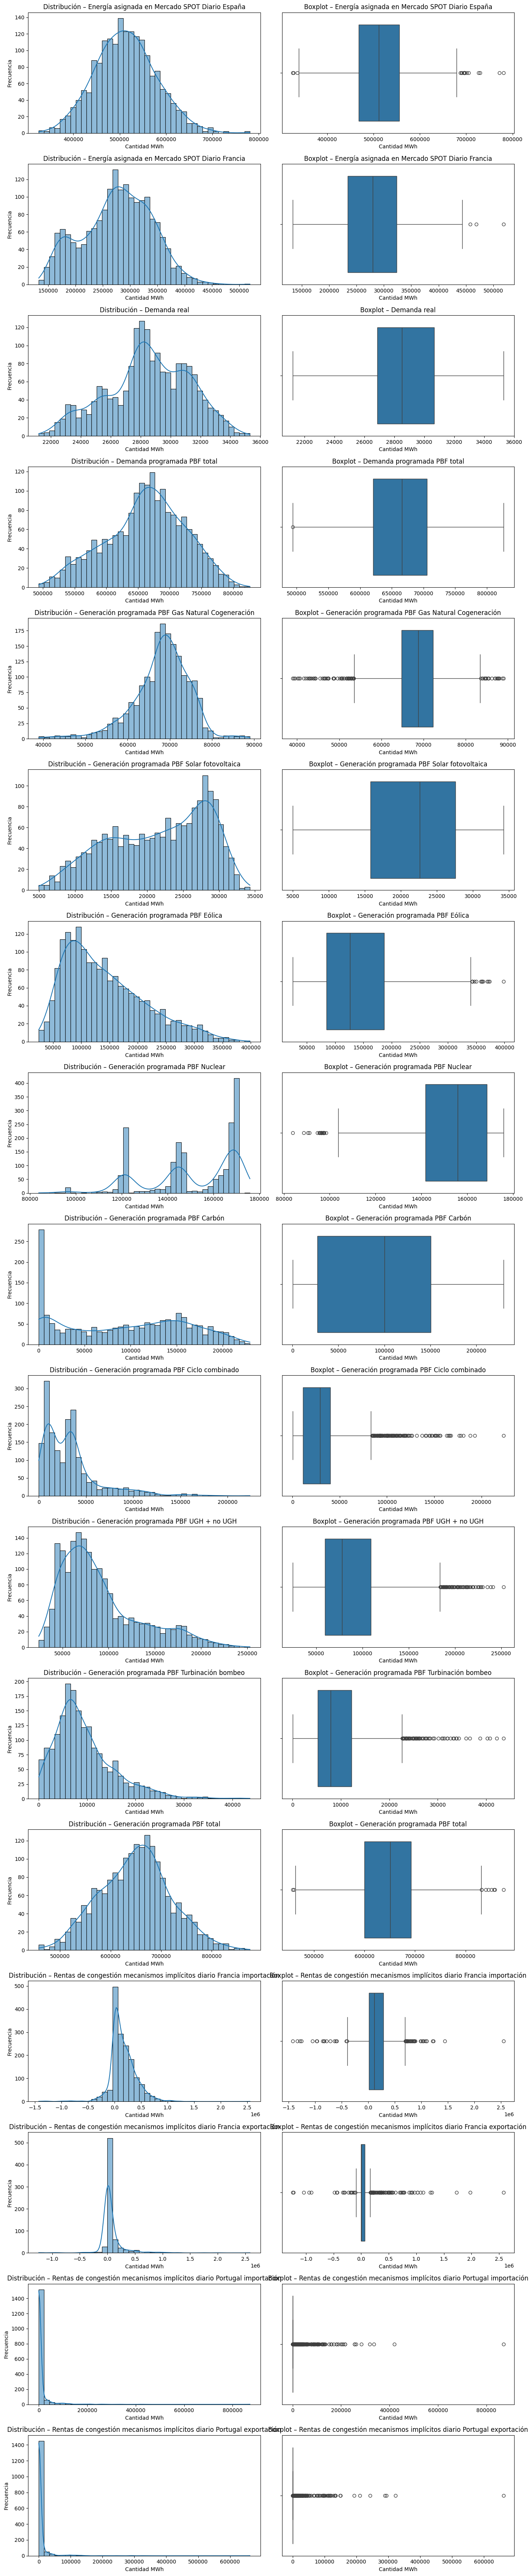

In [28]:
fig, axes = plt.subplots(nrows=len(series2),ncols=2,figsize=(14, 4 * len(series2)))

for i, serie in enumerate(series2):
    data = df[df['name'] == serie]['value']

    # Histograma + KDE
    sns.histplot(
        data=data,
        bins=40,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"Distribución – {serie}")
    axes[i, 0].set_xlabel("Cantidad MWh")
    axes[i, 0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(
        x=data,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot – {serie}")
    axes[i, 1].set_xlabel("Cantidad MWh")

plt.tight_layout()
plt.show()


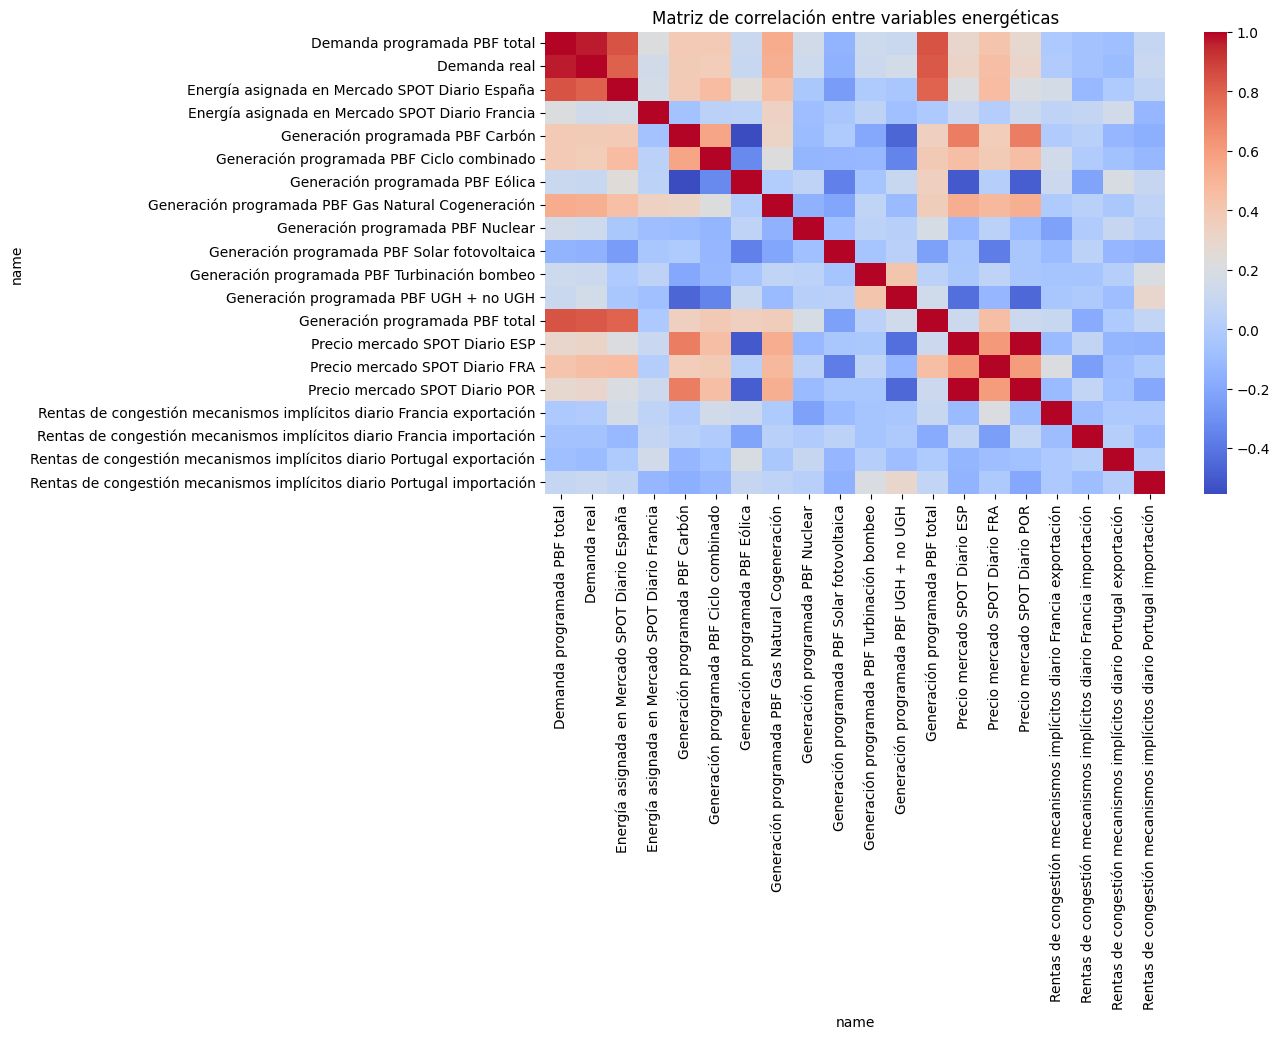

In [29]:
df_wide = df.pivot_table(index="datetime", columns="name", values="value")

plt.figure(figsize=(10,6))
sns.heatmap(df_wide.corr(), annot=False, cmap="coolwarm")
plt.title("Matriz de correlación entre variables energéticas")
plt.show()

In [30]:
precios_spot = [
    "Precio mercado SPOT Diario ESP",
    "Precio mercado SPOT Diario FRA",
    "Precio mercado SPOT Diario POR"
]

df_precio = df[df["name"].isin(precios_spot)].copy()
df_precio.set_index("datetime", inplace=True)

# Asegurar índice temporal
df_precio.index = pd.to_datetime(df_precio.index)

# Variables temporales
df_precio["mes"] = df_precio.index.month

df_precio["estacion"] = pd.cut(
    df_precio["mes"],
    bins=[0, 3, 6, 9, 12],
    labels=["Invierno", "Primavera", "Verano", "Otoño"],
    include_lowest=True
)

<Axes: xlabel='estacion', ylabel='value'>

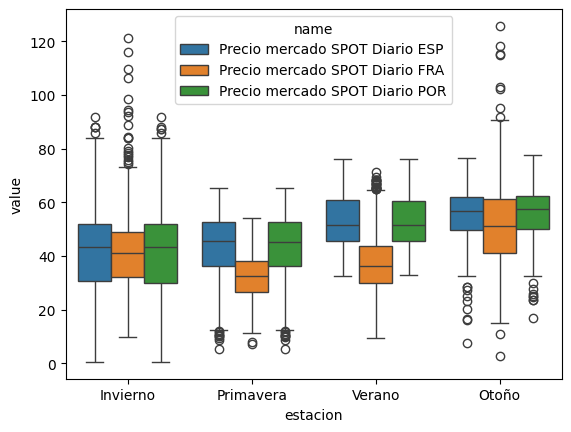

In [31]:
sns.boxplot(x="estacion", y="value", hue="name", data=df_precio)


In [32]:
df_precio = df_precio.sort_index()
df_precio.index = pd.to_datetime(df_precio.index)

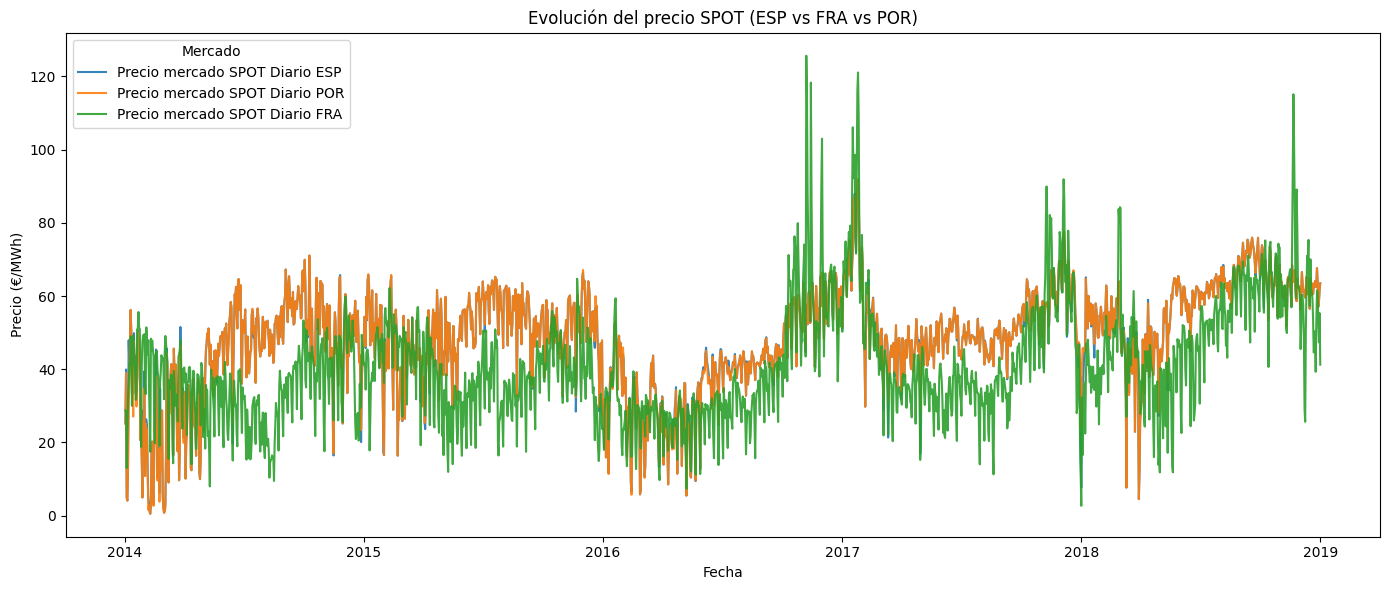

In [33]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_precio, x=df_precio.index, y="value", hue="name", alpha=0.9)
plt.title("Evolución del precio SPOT (ESP vs FRA vs POR)")
plt.xlabel("Fecha")
plt.ylabel("Precio (€/MWh)")
plt.legend(title="Mercado")
plt.tight_layout()
plt.show()
